# MobileNetV2 on CIFAR-10: PTQ, mixed int8, and QAT

I built this notebook to compare four deployment paths on the same backbone:

| Phase | What you get |
|-------|----------------|
| 0 | Toy int8 math (same idea as `mnist_weight_quantization_keras.ipynb`) |
| 1 | FP32 baseline |
| 2 | PTQ (calibrate, then convert) |
| 3 | Mixed model (some layers stay FP32) |
| 4 | QAT (fake quant while training, then convert) |
| 5 | One table + plots from cached test predictions |

**How to run:** cell 1 (setup) -> config -> data -> helpers -> phases 0-5.  
Use kernel **Python 3.12** with CUDA PyTorch if you have a GPU.

In [1]:
import sys
import subprocess
import importlib
import platform

REQUIRED_PY = (3, 12)
TORCH_CUDA_INDEX = "https://download.pytorch.org/whl/cu124"
EXTRA_PACKAGES = ["numpy", "pandas", "ipykernel", "tqdm", "matplotlib", "scikit-learn"]
KERNEL_NAME = "python312"
KERNEL_DISPLAY = "Python 3.12 (PyTorch CUDA)"


def run(cmd, check=True):
    print("  $", " ".join(str(c) for c in cmd))
    return subprocess.run(cmd, check=check, capture_output=True, text=True)


def pip_install(*packages, index_url=None):
    cmd = [sys.executable, "-m", "pip", "install", "--upgrade"]
    if index_url:
        cmd.extend(["--index-url", index_url])
    cmd.extend(packages)
    run(cmd)


def module_version(name):
    try:
        mod = importlib.import_module(name)
        return getattr(mod, "__version__", "installed")
    except ImportError:
        return None


def try_import(name):
    try:
        importlib.import_module(name)
        return True
    except ImportError:
        return False


print("Setup")
print(f"Python: {sys.version.split()[0]} | Platform: {platform.system()}")
# notebook targets Python 3.12

if sys.version_info[:2] != REQUIRED_PY:
    print(f"\nSTOP: this notebook needs Python {REQUIRED_PY[0]}.{REQUIRED_PY[1]}.")
    print(f"Current kernel is Python {sys.version_info.major}.{sys.version_info.minor}.")
    if platform.system() == "Windows":
        print("\nTrying to install Python 3.12 via winget...")
        winget = run(
            [
                "winget", "install", "-e", "--id", "Python.Python.3.12",
                "--accept-package-agreements", "--accept-source-agreements",
            ],
            check=False,
        )
        if winget.stdout:
            print(winget.stdout.strip())
        if winget.stderr:
            print(winget.stderr.strip())
        print("\nThen in a terminal:")
        print('  py -3.12 -m pip install ipykernel')
        print(f'  py -3.12 -m ipykernel install --user --name {KERNEL_NAME} --display-name "{KERNEL_DISPLAY}"')
    else:
        print("\nInstall Python 3.12, then register the ipykernel.")
    print(f'\nIn Jupyter: Kernel -> Change kernel -> "{KERNEL_DISPLAY}"')
    print("Re-run this cell after switching.")
    raise SystemExit("Wrong Python version.")

run([sys.executable, "-m", "ensurepip", "--upgrade"], check=False)
pip_install("pip")

torch_ver = module_version("torch")
tv_ver = module_version("torchvision")
need_torch = torch_ver is None or tv_ver is None
need_cuda_reinstall = torch_ver is not None and "+cu" not in torch_ver

if need_torch:
    print("\nInstalling torch + torchvision (CUDA cu124)...")
    pip_install("torch", "torchvision", index_url=TORCH_CUDA_INDEX)
elif need_cuda_reinstall:
    print(f"\nFound CPU-only torch ({torch_ver}). Reinstalling CUDA build (cu124)...")
    pip_install("torch", "torchvision", index_url=TORCH_CUDA_INDEX)
else:
    print(f"\nOK: torch {torch_ver}, torchvision {tv_ver}")

for pkg in EXTRA_PACKAGES:
    if try_import(pkg):
        print(f"OK: {pkg} {module_version(pkg)}")
    else:
        print(f"Installing {pkg}...")
        pip_install(pkg)

print("\nRegistering Jupyter kernel...")
run(
    [
        sys.executable, "-m", "ipykernel", "install", "--user",
        "--name", KERNEL_NAME, "--display-name", KERNEL_DISPLAY,
    ],
    check=False,
)

import torch
import numpy as np
import pandas as pd

if not try_import("torchvision"):
    pip_install("torchvision", index_url=TORCH_CUDA_INDEX)
import torchvision

torch.backends.quantized.engine = "fbgemm"

cuda_ok = torch.cuda.is_available()
if not cuda_ok and "+cu" in torch.__version__:
    print("\nNOTE: CUDA PyTorch is installed but no GPU is visible.")
    print("  Install/update NVIDIA drivers, then restart.")
    print("  Training will fall back to CPU until CUDA works.")

print("\nSetup summary:")
print(f"Python:       {sys.version.split()[0]}")
print(f"PyTorch:      {torch.__version__}")
print(f"Torchvision:  {torchvision.__version__}")
print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"CUDA:         {cuda_ok}")
if cuda_ok:
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
else:
    print("GPU:          none (CPU training only)")
print(f"Quant engine: {torch.backends.quantized.engine}")
print(f"Jupyter kernel: {KERNEL_DISPLAY}")
print("\nDone. Run the config cell next.")


Setup
Python: 3.12.10 | Platform: Windows
  $ c:\Users\spidy\AppData\Local\Programs\Python\Python312\python.exe -m ensurepip --upgrade
  $ c:\Users\spidy\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

OK: torch 2.6.0+cu124, torchvision 0.21.0+cu124
OK: numpy 2.4.4
OK: pandas 3.0.3
OK: ipykernel 7.2.0
OK: tqdm 4.67.3
OK: matplotlib 3.10.9
Installing scikit-learn...
  $ c:\Users\spidy\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade scikit-learn

Registering Jupyter kernel...
  $ c:\Users\spidy\AppData\Local\Programs\Python\Python312\python.exe -m ipykernel install --user --name python312 --display-name Python 3.12 (PyTorch CUDA)

NOTE: CUDA PyTorch is installed but no GPU is visible.
  Install/update NVIDIA drivers, then restart.
  Training will fall back to CPU until CUDA works.

Setup summary:
Python:       3.12.10
PyTorch:      2.6.0+cu124
Torchvision:  0.21.0+cu124
NumPy:        2.4.4
Pandas:       3.0.3
CUDA:         Fals

## Run order

1. **Setup** (installs deps once)  
2. **Config**  
3. **Data** + **Helpers**  
4. Phases **0-5** in order

In [2]:
import os
import copy
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models.quantization import mobilenet_v2 as q_mobilenet_v2
from torch.ao import quantization as tq
from torch.ao.quantization import QConfigMapping, get_default_qconfig
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display

%matplotlib inline

warnings.filterwarnings("ignore", category=UserWarning)

# --- edit these before a run ---
QUICK_TEST = False
# True  -> 32x32, random init, ~minutes (pipeline check)
# False -> 224x224, ImageNet pretrained, full epochs

EPOCHS_FP32 = 3 if QUICK_TEST else 2
EPOCHS_QAT = 3 if QUICK_TEST else 2
BATCH_SIZE = 64
CALIB_SAMPLES = 512 if QUICK_TEST else 2048  # images for PTQ and mixed calibration
NUM_WORKERS = 0  # Windows: keep 0 or DataLoader workers often hang
SEED = 42

DATA_DIR = "./data"
MODEL_DIR = Path("models")
RESULTS_DIR = Path("results")
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

SAVE_MODEL_FILES = True   # save models/*.pth
SAVE_DEPLOY_MODELS = False  # optional TorchScript under models/
SHOW_PLOTS = True
SHOW_NOTES = True  # phase prints that walk through int8 on real weights
SAVE_CSV = True    # write results/research_report.csv in phase 5

# phase 3 only: middle inverted-res blocks left in FP32 (stem + head always FP32)
MIXED_FP32_BLOCKS = 2

pred_cache = {}  # test preds filled in phases 1-4, read in phase 5
train_histories = {"FP32": None, "QAT": None}

CIFAR10_CLASSES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

IMAGE_SIZE = 32 if QUICK_TEST else 224
USE_IMAGENET_WEIGHTS = not QUICK_TEST

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TRAIN_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
QUANT_DEVICE = torch.device("cpu")  # int8 models evaluated on CPU (fbgemm)
torch.backends.quantized.engine = "fbgemm"

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

print("Mode:", "quick test" if QUICK_TEST else "final")
print("Image size:", f"{IMAGE_SIZE}x{IMAGE_SIZE}")
print("Pretrained:", "ImageNet" if USE_IMAGENET_WEIGHTS else "random init")
print("Train:", TRAIN_DEVICE, "| Quant eval:", QUANT_DEVICE)
print("Epochs (FP32 / QAT):", EPOCHS_FP32, "/", EPOCHS_QAT)
print("Mixed FP32 blocks:", MIXED_FP32_BLOCKS)


c:\Users\spidy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mode: final
Image size: 224x224
Pretrained: ImageNet
Train: cpu | Quant eval: cpu
Epochs (FP32 / QAT): 2 / 2
Mixed FP32 blocks: 2


## Notes

- Train on GPU (`TRAIN_DEVICE`), run quantized models on CPU (`QUANT_DEVICE`).  
- Each model is evaluated on the test set once; phase 5 reuses `pred_cache`.  
- Set `SHOW_NOTES = False` in config if you only want metrics, not the extra printouts.

In [3]:
def build_transforms(image_size, train=True):
    if train:
        if image_size >= 224:
            return transforms.Compose([
                transforms.Resize(256),
                transforms.RandomCrop(image_size),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.2, 0.2, 0.2),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        return transforms.Compose([
            transforms.RandomCrop(image_size, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    if image_size >= 224:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

train_tf = build_transforms(IMAGE_SIZE, train=True)
eval_tf = build_transforms(IMAGE_SIZE, train=False)

train_set = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_tf)
test_set = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=eval_tf)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=TRAIN_DEVICE.type == "cuda")
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=False)

# calibration: eval transforms only (no flip/crop jitter)
calib_base = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=eval_tf)
calib_idx = list(range(min(len(calib_base), CALIB_SAMPLES)))
calib_loader = DataLoader(Subset(calib_base, calib_idx), batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train {len(train_set)} | Test {len(test_set)} | Calib {len(calib_idx)}")


Train 50000 | Test 10000 | Calib 2048


In [4]:


def phase_header(title):
    print(f"\n--- {title} ---\n")

def build_fp32_model(num_classes=10):
    # ImageNet backbone, new 10-class head for CIFAR-10
    weights = MobileNet_V2_Weights.IMAGENET1K_V1 if USE_IMAGENET_WEIGHTS else None
    model = mobilenet_v2(weights=weights)
    in_f = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_f, num_classes)
    return model

def train_epoch(model, loader, criterion, optimizer, device, epoch=1, total_epochs=1, phase="Train"):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    desc = f"{phase} epoch {epoch}/{total_epochs}"
    pbar = tqdm(loader, desc=desc, unit="batch", leave=True)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
        pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{100.0 * correct / total:.1f}%")
    return loss_sum / total, 100.0 * correct / total

def evaluate(model, loader, device, desc="Eval", show_progress=True):
    model.eval()
    correct, total = 0, 0
    it = tqdm(loader, desc=desc, unit="batch", leave=False) if show_progress else loader
    with torch.no_grad():
        for x, y in it:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
            if show_progress:
                it.set_postfix(acc=f"{100.0 * correct / total:.1f}%")
    return 100.0 * correct / total

def disk_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

def ram_mb(model):
    p = sum(p.numel() * p.element_size() for p in model.parameters())
    b = sum(b.numel() * b.element_size() for b in model.buffers())
    return (p + b) / (1024 ** 2)

import io

def estimate_disk_mb(model):
    buf = io.BytesIO()
    torch.save(model.cpu().state_dict(), buf)
    return len(buf.getvalue()) / (1024 ** 2)

def persist_model(model, stem):
    # respects SAVE_MODEL_FILES / SAVE_DEPLOY_MODELS from config
    model = model.cpu().eval()
    state_path = script_path = None
    disk = estimate_disk_mb(model)

    if SAVE_MODEL_FILES:
        state_path = MODEL_DIR / f"{stem}.pth"
        torch.save(model.state_dict(), state_path)
        disk = disk_mb(state_path)
        print(f"  saved: {state_path.name} ({disk:.2f} MB)")

    if SAVE_DEPLOY_MODELS:
        script_path = MODEL_DIR / f"{stem}_scripted.pt"
        try:
            ex = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            traced = torch.jit.trace(model, ex)
            torch.jit.save(traced, script_path)
            print(f"  deploy: {script_path.name} ({disk_mb(script_path):.2f} MB)")
        except Exception as e:
            print(f"  TorchScript skipped for {stem}: {e}")
            script_path = None

    return disk, state_path, script_path

def calibrate(model, loader, desc="Calibrate"):
    # forward passes to fill observer min/max (PTQ / mixed)
    model.eval()
    with torch.no_grad():
        for x, _ in tqdm(loader, desc=desc, unit="batch", leave=False):
            model(x)

def latency_ms(model, loader, device, warmup=5, measure=30):
    model.to(device).eval()
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= warmup:
                break
            model(x.to(device))
    times = []
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= measure:
                break
            x = x.to(device)
            t0 = time.perf_counter()
            model(x)
            times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))

def make_qmodel_from_fp32(fp32_model):
    # same weights as phase 1, fused for torch.ao quant
    m = q_mobilenet_v2(num_classes=10, quantize=False)
    m.load_state_dict(fp32_model.cpu().state_dict())
    m.eval()
    m.fuse_model()
    return m

@torch.no_grad()
def get_predictions(model, loader, device):
    model.to(device).eval()
    y_true, y_pred = [], []
    for x, y in tqdm(loader, desc="Predict", unit="batch", leave=False):
        pred = model(x.to(device)).argmax(1).cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


def eval_and_cache(name, model, loader, device):
    # one test pass; phase 5 reuses pred_cache
    y_true, y_pred = get_predictions(model, loader, device)
    acc = 100.0 * (y_true == y_pred).mean()
    pred_cache[name] = (y_true, y_pred, acc)
    return acc


def draw_confusion_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    acc = 100.0 * (y_true == y_pred).mean()
    ax.imshow(cm, cmap=plt.cm.Blues)
    ax.set_title(f"{title}\naccuracy {acc:.1f}%")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(CIFAR10_CLASSES, fontsize=8)
    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i, j in itertools.product(range(10), range(10)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=7)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    return cm, acc

def draw_training_curves(history, title):
    ep = history.get("epoch", [])
    if not ep:
        print(f"  [skip] No training history for {title}. Re-run that training phase.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    marker = "o"
    ms = 7 if len(ep) <= 5 else 5
    lw = 2 if len(ep) > 1 else 0

    axes[0].plot(ep, history["train_acc"], label="Train", marker=marker, linewidth=lw, markersize=ms)
    axes[0].plot(ep, history["test_acc"], label="Test", marker=marker, linewidth=lw, markersize=ms)
    axes[0].set_title(f"{title} — accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("accuracy (%)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    if len(ep) == 1:
        axes[0].set_xlim(0.5, 1.5)
    lo = min(history["train_acc"] + history["test_acc"])
    hi = max(history["train_acc"] + history["test_acc"])
    pad = max(2.0, (hi - lo) * 0.15) if hi != lo else 5.0
    axes[0].set_ylim(lo - pad, hi + pad)

    axes[1].plot(ep, history["train_loss"], label="Train loss", marker=marker, linewidth=lw, markersize=ms)
    axes[1].set_title(f"{title} — loss")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    if len(ep) == 1:
        axes[1].set_xlim(0.5, 1.5)
    lo = min(history["train_loss"])
    hi = max(history["train_loss"])
    pad = max(0.05, (hi - lo) * 0.15) if hi != lo else 0.5
    axes[1].set_ylim(lo - pad, hi + pad)

    plt.tight_layout()
    return fig

Q_MIN, Q_MAX = -128, 127
# used by note_* helpers when SHOW_NOTES is True

def get_stem_conv(model):
    # after fuse_model the conv may sit inside features[0][0][0]
    stem = model.features[0][0]
    if hasattr(stem, "weight"):
        return stem
    return stem[0]

def get_stem_block(model):
    return model.features[0][0]

def observer_qparams(observer):
    scale, zp = observer.calculate_qparams()
    s = float(scale.flatten()[0].item())
    z = int(zp.flatten()[0].item())
    return s, z

def calc_scale_zero_point(r_min, r_max, q_min=Q_MIN, q_max=Q_MAX):
    scale = (r_max - r_min) / (q_max - q_min)
    zp = int(max(q_min, min(q_max, q_min - round(r_min / scale))))
    return scale, zp

def quantize_array(arr, scale, zero_point, q_min=Q_MIN, q_max=Q_MAX):
    q = np.round(arr / scale + zero_point)
    return np.clip(q, q_min, q_max)

def dequantize_array(q, scale, zero_point):
    return scale * (q - zero_point)

def symmetric_scale(arr, q_min=Q_MIN, q_max=Q_MAX):
    max_abs = max(abs(arr.min()), abs(arr.max()))
    return max_abs / max(abs(q_min), abs(q_max)), 0

def print_quant_demo(title, float_array):
    arr = np.asarray(float_array, dtype=np.float64)
    print(f"\n{title}")
    print(f"values: {arr}")
    print(f"Range: min={arr.min():.3f}, max={arr.max():.3f}")

    print("\n--- Asymmetric Quantization ---")
    s, z = calc_scale_zero_point(arr.min(), arr.max())
    q = quantize_array(arr, s, z)
    recon = dequantize_array(q, s, z)
    print(f"Scale (S): {s:.6f}")
    print(f"Zero point (Z): {z}")
    print(f"Quantized values: {q.astype(int)}")
    print(f"Reconstructed values: {recon}")
    print(f"Mean Squared Error: {np.mean((arr - recon) ** 2):.6f}")

    print("\n--- Symmetric Quantization ---")
    ss, zs = symmetric_scale(arr)
    qs = quantize_array(arr, ss, zs)
    recons = dequantize_array(qs, ss, zs)
    print(f"Scale (S): {ss:.6f}")
    print(f"Zero point (Z): {zs}")
    print(f"Quantized values: {qs.astype(int)}")
    print(f"Reconstructed values: {recons}")
    print(f"Mean Squared Error: {np.mean((arr - recons) ** 2):.6f}")

def note_fp32(model):
    conv = get_stem_conv(model)
    w = conv.weight.data.flatten()[:6].cpu().numpy()
    print("FP32 stem conv (no quant yet)")
    print(f"First conv dtype: {conv.weight.dtype}")
    print(f"Sample weights (6): {w}")

def note_ptq_calibrated(prepared, fp32_model):
    block = get_stem_block(prepared)
    print("PTQ after calibration")
    print("Calibration pass fills observers (min/max -> scale and zero_point).")
    print("On fused ConvReLU blocks you see activation observers, not weight_fake_quant yet.")
    if hasattr(block, "activation_post_process"):
        s, z = observer_qparams(block.activation_post_process)
        print(f"Stem activation observer: scale={s:.6f}, zero_point={z}")
    sample = get_stem_conv(fp32_model).weight.data.flatten()[:6].cpu().numpy()
    print_quant_demo("Same weights by hand (asymmetric vs symmetric)", sample)

def note_ptq_converted(q_model, fp32_model):
    qlayer = get_stem_block(q_model)
    qw = qlayer.weight()
    fp32_w = get_stem_conv(fp32_model).weight.data.flatten()[:6].cpu().numpy()
    int_w = qw.int_repr().flatten()[:6].numpy()
    dq_w = qw.dequantize().flatten()[:6].numpy()
    scale = getattr(qlayer, "scale", None)
    zp = getattr(qlayer, "zero_point", 0)
    print("PTQ after convert (weights stored as int8)")
    print("Formula: dequant = scale * (int8 - zero_point)")
    print(f"scale={scale}, zero_point={zp}")
    print(f"FP32 original:    {fp32_w}")
    print(f"Stored int8:      {int_w}")
    print(f"Dequantized:      {dq_w}")
    print(f"MSE (6 weights):  {np.mean((fp32_w - dq_w) ** 2):.6f}")

def note_mixed(n_fp32_blocks):
    print("Mixed FP32 + int8")
    print(f"Keep FP32: stem + {n_fp32_blocks} middle blocks + classifier")
    print("Rest: int8. FX inserts quant/dequant at borders.")

def note_qat(qat_model, fp32_model):
    block = get_stem_block(qat_model)
    if not hasattr(block, "weight_fake_quant"):
        raise AttributeError(
            f"{type(block).__name__} has no weight_fake_quant. "
            "Did you call prepare_qat in training mode?"
        )
    fq = block.weight_fake_quant
    print("QAT (fake quant during training)")
    print("Weights still float on disk, but forward simulates int8 error.")
    s = float(fq.scale.flatten()[0].item())
    z = int(fq.zero_point.flatten()[0].item())
    print(f"Fake-quant scale={s:.6f}, Z={z}")
    sample = get_stem_conv(fp32_model).weight.data.flatten()[:6].cpu().numpy()
    print_quant_demo("Sample weights through quant math", sample)


In [5]:
phase_header("Phase 0 / toy quant")
print("q = round(x/S + Z),  recover with  x_hat = S * (q - Z)")

toy = np.array([2.1, -0.98, 1.48, 0.09, -1.08, 2.12])
print_quant_demo("Toy weights", toy)
print("Phases 1-4 apply the same idea to MobileNetV2 weights.")
print("Set SHOW_NOTES = False in config to hide these extra prints.")


--- Phase 0 / toy quant ---

q = round(x/S + Z),  recover with  x_hat = S * (q - Z)

Toy weights
values: [ 2.1  -0.98  1.48  0.09 -1.08  2.12]
Range: min=-1.080, max=2.120

--- Asymmetric Quantization ---
Scale (S): 0.012549
Zero point (Z): -42
Quantized values: [ 125 -120   76  -35 -128  127]
Reconstructed values: [ 2.09568627 -0.97882353  1.48078431  0.08784314 -1.07921569  2.12078431]
Mean Squared Error: 0.000004

--- Symmetric Quantization ---
Scale (S): 0.016563
Zero point (Z): 0
Quantized values: [127 -59  89   5 -65 127]
Reconstructed values: [ 2.1034375 -0.9771875  1.4740625  0.0828125 -1.0765625  2.1034375]
Mean Squared Error: 0.000065
Phases 1-4 apply the same idea to MobileNetV2 weights.
Set SHOW_NOTES = False in config to hide these extra prints.


In [6]:
phase_header("Phase 1 / FP32 baseline")

model_fp32 = build_fp32_model().to(TRAIN_DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_fp32.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

best_acc, best_state = 0.0, None
fp32_history = {"epoch": [], "train_loss": [], "train_acc": [], "test_acc": []}
for ep in range(EPOCHS_FP32):
    loss, tr_acc = train_epoch(
        model_fp32, train_loader, criterion, optimizer, TRAIN_DEVICE,
        epoch=ep + 1, total_epochs=EPOCHS_FP32, phase="FP32",
    )
    te_acc = evaluate(model_fp32, test_loader, TRAIN_DEVICE, desc=f"FP32 test {ep+1}/{EPOCHS_FP32}")
    print(f"Epoch {ep+1}/{EPOCHS_FP32} done | loss {loss:.4f} | train {tr_acc:.2f}% | test {te_acc:.2f}%")
    fp32_history["epoch"].append(ep + 1)
    fp32_history["train_loss"].append(loss)
    fp32_history["train_acc"].append(tr_acc)
    fp32_history["test_acc"].append(te_acc)
    if te_acc > best_acc:
        best_acc = te_acc
        best_state = copy.deepcopy(model_fp32.state_dict())

train_histories["FP32"] = {k: list(v) for k, v in fp32_history.items()}
print(f"Saved {len(fp32_history['epoch'])} FP32 epochs for Phase 5 plots")

model_fp32.load_state_dict(best_state)
acc_fp32 = eval_and_cache("FP32", model_fp32, test_loader, TRAIN_DEVICE)
fp32_disk, _, _ = persist_model(model_fp32, "mobilenetv2_fp32")
model_fp32 = model_fp32.to(TRAIN_DEVICE)
mem_fp32 = ram_mb(model_fp32)
print(f"FP32 | disk {fp32_disk:.2f} MB | RAM {mem_fp32:.2f} MB")

if SHOW_NOTES:
    note_fp32(model_fp32.cpu())



--- Phase 1 / FP32 baseline ---



FP32 epoch 1/2: 100%|██████████| 782/782 [54:11<00:00,  4.16s/batch, acc=81.6%, loss=0.798]


Epoch 1/2 done | loss 0.5339 | train 81.57% | test 88.53%


FP32 epoch 2/2: 100%|██████████| 782/782 [52:22<00:00,  4.02s/batch, acc=89.4%, loss=0.256]


Epoch 2/2 done | loss 0.3095 | train 89.39% | test 87.12%
Saved 2 FP32 epochs for Phase 5 plots


  saved: mobilenetv2_fp32.pth (8.76 MB)
FP32 | disk 8.76 MB | RAM 8.66 MB
FP32 stem conv (no quant yet)
First conv dtype: torch.float32
Sample weights (6): [ 0.01308381 -0.00428803  0.01470898  0.03252783 -0.02518948  0.00680435]


In [7]:
phase_header("Phase 2 / PTQ int8")

ptq_model = make_qmodel_from_fp32(model_fp32)
ptq_model.qconfig = tq.get_default_qconfig("fbgemm")
tq.prepare(ptq_model, inplace=True)
print("Calibrating...")
calibrate(ptq_model, calib_loader, desc="PTQ calibrate")

if SHOW_NOTES:
    note_ptq_calibrated(ptq_model, model_fp32.cpu())

model_ptq_int8 = tq.convert(ptq_model, inplace=False)

if SHOW_NOTES:
    note_ptq_converted(model_ptq_int8, model_fp32.cpu())

acc_ptq = eval_and_cache("PTQ_int8", model_ptq_int8, test_loader, QUANT_DEVICE)  # CPU + fbgemm
ptq_disk, _, _ = persist_model(model_ptq_int8, "mobilenetv2_ptq_int8")
mem_ptq = ram_mb(model_ptq_int8)
print(f"PTQ | drop vs FP32 {acc_fp32-acc_ptq:.2f}% | disk {ptq_disk:.2f} MB")



--- Phase 2 / PTQ int8 ---

Calibrating...


PTQ after calibration
Calibration pass fills observers (min/max -> scale and zero_point).
On fused ConvReLU blocks you see activation observers, not weight_fake_quant yet.
Stem activation observer: scale=0.023843, zero_point=0

Same weights by hand (asymmetric vs symmetric)
values: [ 0.01308381 -0.00428803  0.01470898  0.03252783 -0.02518948  0.00680435]
Range: min=-0.025, max=0.033

--- Asymmetric Quantization ---
Scale (S): 0.000226
Zero point (Z): -17
Quantized values: [  41  -36   48  127 -128   13]
Reconstructed values: [ 0.01312786 -0.00430051  0.01471226  0.03259331 -0.02512401  0.00679027]
Mean Squared Error: 0.000000

--- Symmetric Quantization ---
Scale (S): 0.000254
Zero point (Z): 0
Quantized values: [ 51 -17  58 127 -99  27]
Reconstructed values: [ 0.01296031 -0.0043201   0.01473917  0.03227371 -0.02515825  0.00686134]
Mean Squared Error: 0.000000
PTQ after convert (weights stored as int8)
Formula: dequant = scale * (int8 - zero_point)
scale=0.023843491449952126, zero_poin

  saved: mobilenetv2_ptq_int8.pth (2.54 MB)
PTQ | drop vs FP32 2.71% | disk 2.54 MB


In [8]:
phase_header("Phase 3 / mixed FP32 + int8")

def build_mixed_model(fp32_model, n_fp32_blocks):
    model = copy.deepcopy(fp32_model).cpu().eval()
    example = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
    qm = QConfigMapping().set_global(get_default_qconfig("fbgemm"))
    qm.set_module_name("features.0", None)
    # None = leave module in FP32
    qm.set_module_name("classifier.1", None)
    # then features.1 .. features.N from MIXED_FP32_BLOCKS
    for i in range(1, 1 + n_fp32_blocks):
        if i < len(model.features):
            qm.set_module_name(f"features.{i}", None)
    print(f"  FP32: stem + {n_fp32_blocks} blocks + classifier | rest int8")
    prepared = prepare_fx(model, qm, example)
    calibrate(prepared, calib_loader, desc="Mixed calibrate")
    return convert_fx(prepared)

model_mixed = build_mixed_model(model_fp32, MIXED_FP32_BLOCKS)
acc_mixed = eval_and_cache("Mixed", model_mixed, test_loader, QUANT_DEVICE)
mixed_disk, _, _ = persist_model(model_mixed, "mobilenetv2_mixed")
mem_mixed = ram_mb(model_mixed)
print(f"Mixed | drop vs FP32 {acc_fp32-acc_mixed:.2f}% | disk {mixed_disk:.2f} MB")

if SHOW_NOTES:
    note_mixed(MIXED_FP32_BLOCKS)



--- Phase 3 / mixed FP32 + int8 ---

  FP32: stem + 2 blocks + classifier | rest int8


  saved: mobilenetv2_mixed.pth (2.57 MB)
Mixed | drop vs FP32 0.72% | disk 2.57 MB
Mixed FP32 + int8
Keep FP32: stem + 2 middle blocks + classifier
Rest: int8. FX inserts quant/dequant at borders.


In [9]:
phase_header("Phase 4 / QAT")

qat_model = make_qmodel_from_fp32(model_fp32)
qat_model.train()
qat_model.qconfig = tq.get_default_qat_qconfig("fbgemm")
tq.prepare_qat(qat_model, inplace=True)
qat_model = qat_model.to(TRAIN_DEVICE)

if SHOW_NOTES:
    note_qat(qat_model, model_fp32.cpu())

# lower lr than FP32; weights already trained in phase 1
opt_qat = optim.SGD(qat_model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-4)
best_qat, best_qat_state = 0.0, None
qat_history = {"epoch": [], "train_loss": [], "train_acc": [], "test_acc": []}

for ep in range(EPOCHS_QAT):
    loss, tr_acc = train_epoch(
        qat_model, train_loader, criterion, opt_qat, TRAIN_DEVICE,
        epoch=ep + 1, total_epochs=EPOCHS_QAT, phase="QAT",
    )
    te_acc = evaluate(qat_model, test_loader, TRAIN_DEVICE, desc=f"QAT test {ep+1}/{EPOCHS_QAT}")
    print(f"  >> Epoch {ep+1}/{EPOCHS_QAT} done | loss {loss:.4f} | train {tr_acc:.2f}% | test {te_acc:.2f}%")
    qat_history["epoch"].append(ep + 1)
    qat_history["train_loss"].append(loss)
    qat_history["train_acc"].append(tr_acc)
    qat_history["test_acc"].append(te_acc)
    if te_acc > best_qat:
        best_qat = te_acc
        best_qat_state = copy.deepcopy(qat_model.state_dict())

qat_model.load_state_dict(best_qat_state)
qat_model.eval().cpu()

qat_convert_ok = False
qat_label = "QAT_int8"
try:
    model_qat_int8 = tq.convert(qat_model, inplace=False)
    qat_convert_ok = True
    acc_qat = eval_and_cache("QAT_int8", model_qat_int8, test_loader, QUANT_DEVICE)
    qat_disk, _, _ = persist_model(model_qat_int8, "mobilenetv2_qat_int8")
    mem_qat = ram_mb(model_qat_int8)
    print(f"QAT int8 | vs PTQ {acc_qat - acc_ptq:+.2f}% | disk {qat_disk:.2f} MB")
    if SHOW_NOTES:
        print("\nQAT convert done — int8 with scales from training:")
        note_ptq_converted(model_qat_int8, model_fp32.cpu())
except Exception as e:
    qat_label = "QAT_fakequant"
    print(f"QAT convert failed: {e}")
    model_qat_int8 = qat_model
    acc_qat = eval_and_cache("QAT_fakequant", qat_model, test_loader, QUANT_DEVICE)
    qat_disk = estimate_disk_mb(qat_model)
    mem_qat = ram_mb(qat_model)
    print(f"QAT fake-quant only | acc {acc_qat:.2f}%")



--- Phase 4 / QAT ---

QAT (fake quant during training)
Weights still float on disk, but forward simulates int8 error.
Fake-quant scale=1.000000, Z=0

Sample weights through quant math
values: [ 0.01308381 -0.00428803  0.01470898  0.03252783 -0.02518948  0.00680435]
Range: min=-0.025, max=0.033

--- Asymmetric Quantization ---
Scale (S): 0.000226
Zero point (Z): -17
Quantized values: [  41  -36   48  127 -128   13]
Reconstructed values: [ 0.01312786 -0.00430051  0.01471226  0.03259331 -0.02512401  0.00679027]
Mean Squared Error: 0.000000

--- Symmetric Quantization ---
Scale (S): 0.000254
Zero point (Z): 0
Quantized values: [ 51 -17  58 127 -99  27]
Reconstructed values: [ 0.01296031 -0.0043201   0.01473917  0.03227371 -0.02515825  0.00686134]
Mean Squared Error: 0.000000


QAT epoch 1/2: 100%|██████████| 782/782 [1:03:30<00:00,  4.87s/batch, acc=92.0%, loss=0.075]


  >> Epoch 1/2 done | loss 0.2319 | train 91.96% | test 92.59%


QAT epoch 2/2: 100%|██████████| 782/782 [1:26:54<00:00,  6.67s/batch, acc=93.8%, loss=0.092]  


  >> Epoch 2/2 done | loss 0.1820 | train 93.78% | test 93.04%


  saved: mobilenetv2_qat_int8.pth (2.54 MB)
QAT int8 | vs PTQ +7.28% | disk 2.54 MB

QAT convert done — int8 with scales from training:
PTQ after convert (weights stored as int8)
Formula: dequant = scale * (int8 - zero_point)
scale=0.025771209970116615, zero_point=0
FP32 original:    [ 0.01308381 -0.00428803  0.01470898  0.03252783 -0.02518948  0.00680435]
Stored int8:      [ 45 -15  51 112 -87  23]
Dequantized:      [ 0.00199311 -0.00066437  0.00225885  0.00496062 -0.00385334  0.0010187 ]
MSE (6 weights):  0.000257



--- Phase 5 / comparison report ---

FP32            acc 88.53%  F1 0.885  disk 8.76 MB  700.4 ms/batch
PTQ_int8        acc 85.82%  F1 0.859  disk 2.53 MB  167.1 ms/batch
Mixed           acc 87.81%  F1 0.878  disk 2.57 MB  345.3 ms/batch
QAT_int8        acc 93.10%  F1 0.931  disk 2.53 MB  162.7 ms/batch

=== TABLE 1: Model comparison ===


,model,phase,accuracy_pct,acc_drop_vs_fp32,macro_f1,disk_mb,ram_mb,latency_ms,speedup_vs_fp32
0,FP32,baseline,88.53,0.00,0.885,8.76,8.66,700.44,1.00
1,PTQ_int8,PTQ,85.82,2.71,0.859,2.53,0.00,167.05,4.19
2,Mixed,Mixed,87.81,0.72,0.878,2.57,0.07,345.29,2.03
3,QAT_int8,QAT,93.10,-4.57,0.931,2.53,0.00,162.73,4.30



=== TABLE 2: Per-class F1 ===


,FP32,PTQ_int8,Mixed,QAT_int8
class,,,,
airplane,0.895,0.874,0.885,0.937
automobile,0.946,0.940,0.948,0.966
bird,0.858,0.817,0.850,0.918
cat,0.762,0.750,0.753,0.857
deer,0.869,0.827,0.856,0.927
dog,0.819,0.796,0.809,0.880
frog,0.919,0.900,0.913,0.961
horse,0.912,0.875,0.905,0.949
ship,0.931,0.903,0.928,0.956



Backup: results/research_report.csv

=== Training curves (weight_q style) ===
  FP32: 2 epoch(s) in history


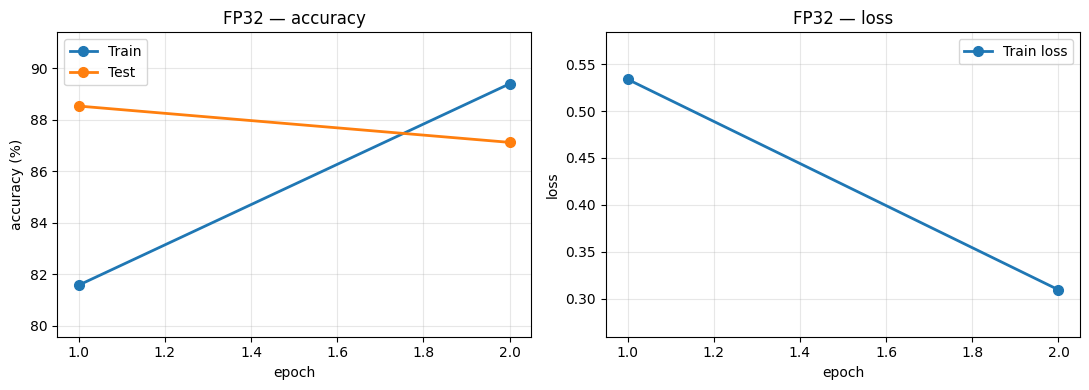

  QAT: 2 epoch(s) in history


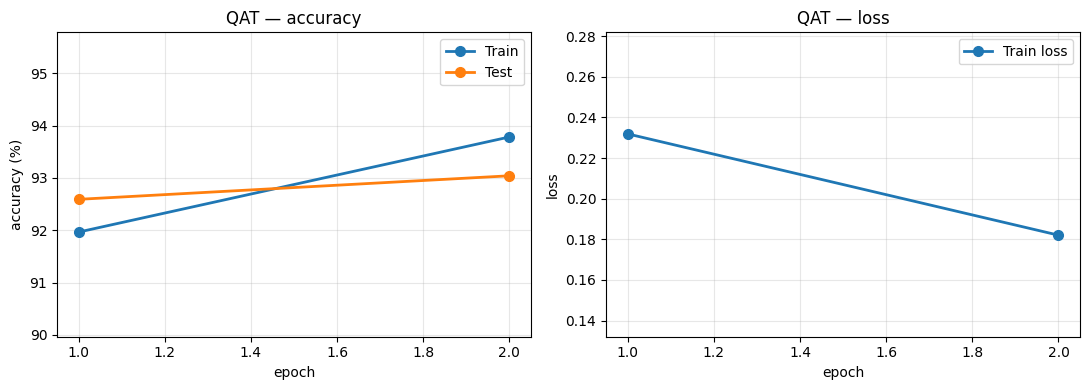


=== Confusion matrices (from cache) ===


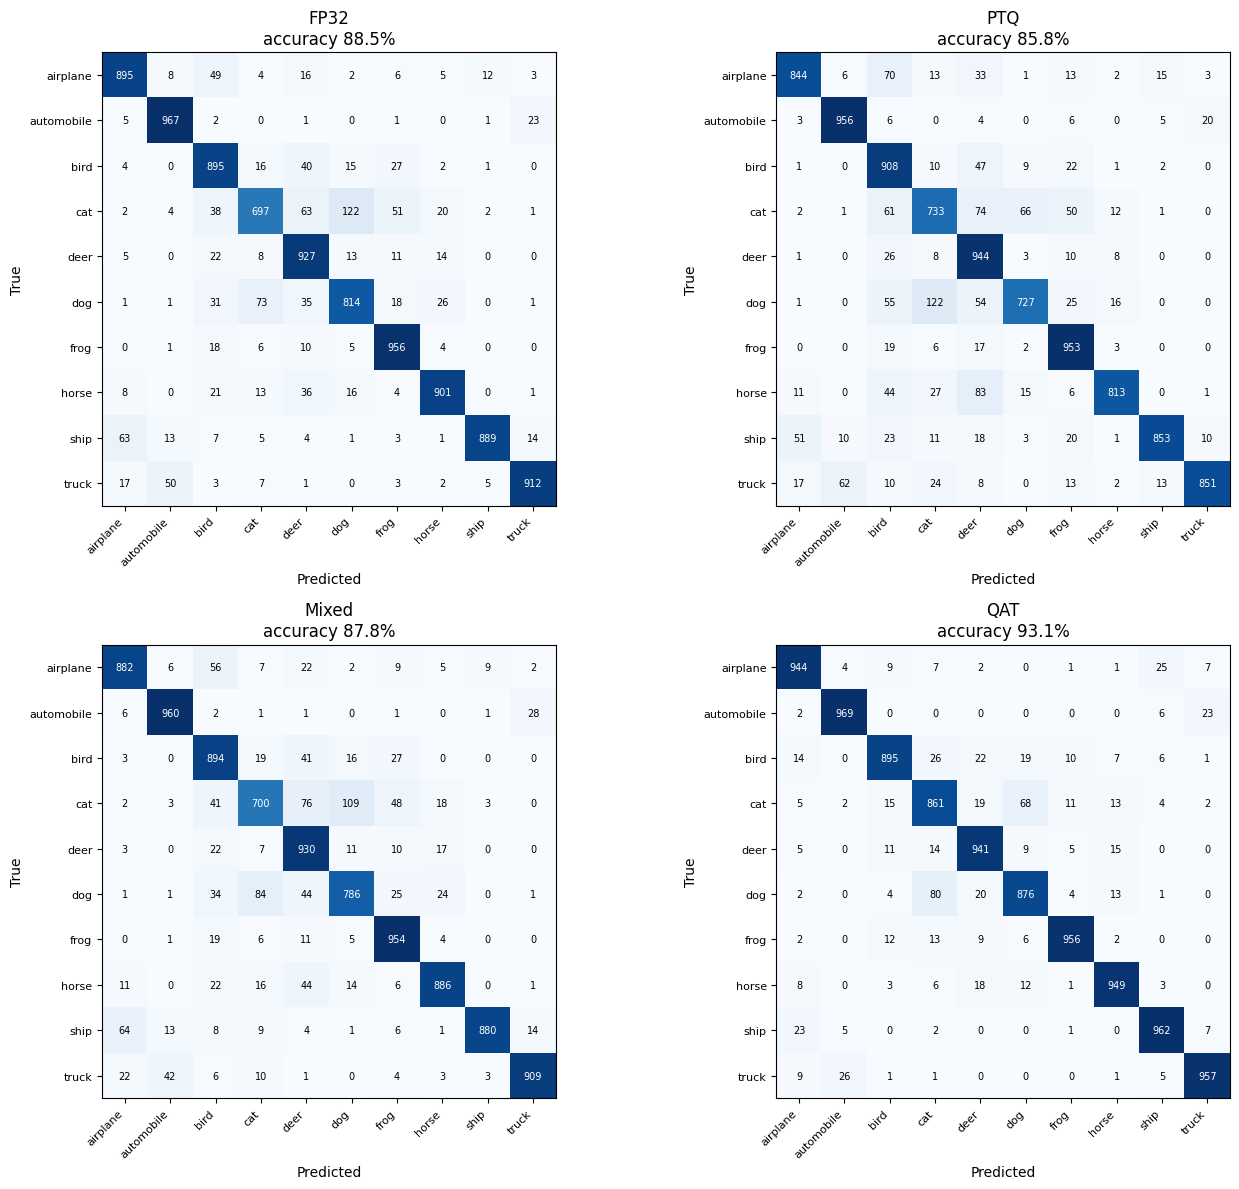


Done — all models compared above.


In [ ]:
phase_header("Phase 5 / comparison report")

report_models = [
    ("FP32", model_fp32.cpu(), "baseline"),
    ("PTQ_int8", model_ptq_int8, "PTQ"),
    ("Mixed", model_mixed, "Mixed"),
    (qat_label, model_qat_int8 if qat_convert_ok else qat_model, "QAT"),
]

report_rows = []
f1_by_model = {"class": list(CIFAR10_CLASSES)}
fp32_lat = None

for name, model, phase in report_models:
    # acc from pred_cache; latency is the only extra forward pass here
    y_true, y_pred, acc = pred_cache[name]
    rep = classification_report(y_true, y_pred, target_names=CIFAR10_CLASSES, output_dict=True, zero_division=0)
    macro_f1 = rep["macro avg"]["f1-score"]
    f1_by_model[name] = [rep[c]["f1-score"] for c in CIFAR10_CLASSES]

    sz = estimate_disk_mb(model)
    mem = ram_mb(model)
    lat, _ = latency_ms(model, test_loader, QUANT_DEVICE)
    if fp32_lat is None:
        fp32_lat = lat

    report_rows.append({
        "model": name,
        "phase": phase,
        "accuracy_pct": round(acc, 2),
        "acc_drop_vs_fp32": round(pred_cache["FP32"][2] - acc, 2),
        "macro_f1": round(macro_f1, 3),
        "disk_mb": round(sz, 2),
        "ram_mb": round(mem, 2),
        "latency_ms": round(lat, 2),
        "speedup_vs_fp32": round(fp32_lat / lat, 2) if lat > 0 else None,
    })
    print(f"{name:14s}  acc {acc:5.2f}%  F1 {macro_f1:.3f}  disk {sz:.2f} MB  {lat:.1f} ms/batch")

df_report = pd.DataFrame(report_rows)
print("\n=== TABLE 1: Model comparison ===")
display(df_report)

df_f1 = pd.DataFrame(f1_by_model).set_index("class")
print("\n=== TABLE 2: Per-class F1 ===")
display(df_f1.round(3))

if SAVE_CSV:
    df_report.to_csv(RESULTS_DIR / "research_report.csv", index=False)
    print("\nBackup: results/research_report.csv")

if SHOW_PLOTS:
    print("\n=== Training curves ===")
    for plot_title, hist_key in [("FP32", "FP32"), ("QAT", "QAT")]:
        hist = train_histories.get(hist_key)
        if hist is None:
            try:
                hist = fp32_history if hist_key == "FP32" else qat_history
            except NameError:
                print(f"  [skip] {plot_title}: no history. Re-run Phase {'1' if hist_key == 'FP32' else '4'}.")
                continue
        n_ep = len(hist.get("epoch", [])) if hist else 0
        print(f"  {plot_title}: {n_ep} epoch(s) in history")
        fig = draw_training_curves(hist, plot_title)
        if fig is not None:
            display(fig)
            plt.close(fig)

    print("\n=== Confusion matrices (from cache) ===")
    cm_keys = ["FP32", "PTQ_int8", "Mixed", qat_label]
    cm_titles = ["FP32", "PTQ", "Mixed", "QAT"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for ax, key, title in zip(axes.flatten(), cm_keys, cm_titles):
        y_true, y_pred, _ = pred_cache[key]
        draw_confusion_matrix(ax, y_true, y_pred, title)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

print("\nDone — all models compared above.")
